In [1]:
import numpy as np
from pydub import AudioSegment
import random
import sys
import io
import os
import glob
import IPython
from td_utils import *
%matplotlib inline

/usr/local/lib/python3.11/dist-packages/pydub/utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)


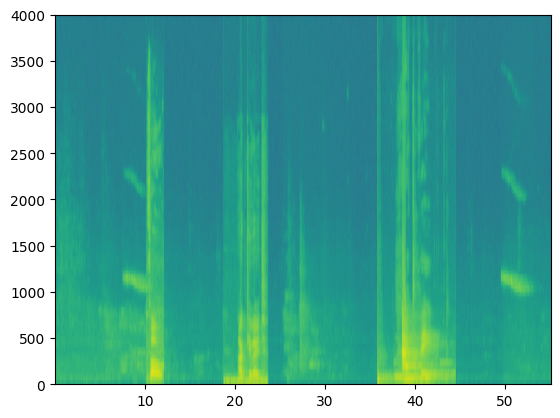

In [2]:
x = graph_spectrogram("audio_examples/example_train.wav")
_, data = wavfile.read("audio_examples/example_train.wav")
Tx = 5511 # The number of time steps input to the model from the spectrogram
n_freq = 101 # Number of frequencies input to the model at each time step of the spectrogram
Ty = 1375 # The number of time steps in the output of our model
activates, negatives, backgrounds = load_raw_audio('./raw_data/')

# Data synthesis
In this section we will create new training data from 3 sources: 
* Background noises
* Activate (trigger word)
* Other words (irrelevant to system)

Background noises are 10 seconds long, words(activate and others) are approximately 1 second long, but they vary in the duration.
Our goal is to add 0-4 activation words, and additionaly 0-2 other words. We will **NOT** change  the length of the audio, it will
be 10 seconds long.

## Helper functions
*get_random_time_segment(segment_ms)*:  <br>
This function creates random time segment with duration of segment_ms(word clip length)  <br>
*is_overlapping(segment_time, existing_segments)*: <br>
This function will check, if (random) interval of the duration of added word overlaps the other words previously added 
to the background <br>
*insert_audio_clip(background, audio_clip, existing_times)*: <br>
This function inserts audio_clip to background <br>
*insert_ones(y, segment_end_ms)*: <br>
This function inserts ones to output, after end of audioclip and in 49 additional timesteps right after the end <br>


In [3]:
def get_random_time_segment(segment_ms):
    interval_start = np.random.randint(low=0, high=10000-segment_ms)
    interval_end = interval_start + segment_ms - 1
    return (interval_start, interval_end)

In [4]:
def is_overlapping(segment_time, existing_segments):
    left, right = segment_time
    for (start, end) in existing_segments:
        if left<=end and right >= start:
            return True
    return False

In [5]:
def insert_audio_clip(background, audio_clip, existing_times):
    retry = 5
    segment_ms = len(audio_clip)
    new_time = get_random_time_segment(segment_ms) 
    while is_overlapping(new_time, existing_times) and retry >= 0:
        new_time = get_random_time_segment(segment_ms)
        retry -= 1
    if not is_overlapping(new_time, existing_times):
        existing_times.append(new_time)
        new_background = background.overlay(audio_clip, position=new_time[0])
    else:
        new_background = background
        new_time = (10000, 10000)
    return new_background, new_time

In [6]:
def insert_ones(y, segment_end_ms):
    _, Ty = y.shape
    segment_end_y = int(segment_end_ms * Ty / 10000.0)+1
    if segment_end_y < Ty:
        for i in range(segment_end_y, segment_end_y+50):
            if i<Ty:
                y[0,i] = 1
    return y

## Creating training examples

In [7]:
def create_training_example(background, activates, negatives, Ty):
    background = background - 20 
    y = np.zeros((1, Ty))
    existing_times = list()

    
    qty_act = np.random.randint(low=0, high=5)
    rand_idx = np.random.randint(len(activates), size=qty_act)
    rand_act = [activates[i] for i in rand_idx]

    for act in rand_act:
        background, segment_time=insert_audio_clip(background, act, existing_times)
        y = insert_ones(y, segment_time[0])

    qty_neg = np.random.randint(low=0, high=3)
    rand_idx = np.random.randint(len(negatives), size=qty_neg)
    rand_neg = [negatives[i] for i in rand_idx]

    for neg in rand_neg:
        background, _ =insert_audio_clip(background, neg, existing_times)

    background = match_target_amplitude(background, -20)
    file_handle = background.export("train"+".wav", format="wav")
    x = graph_spectrogram("train.wav")

    return x, y

0
100


/usr/local/lib/python3.11/dist-packages/matplotlib/axes/_axes.py:8283: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)


200
300
400
500
600
700
800
ok


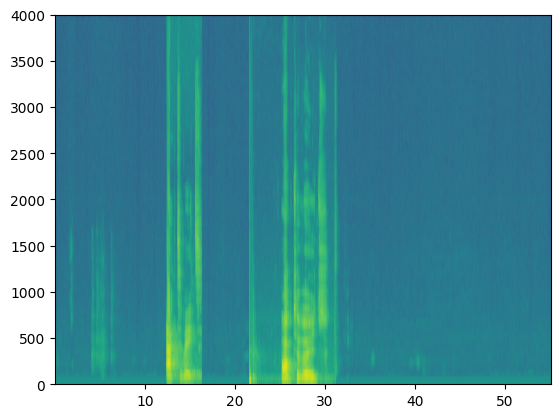

In [8]:
nsamples = 801
X = []
Y = []
for i in range(0, nsamples):
    if i%100 == 0:
        print(i)
    x, y = create_training_example(backgrounds[i % 2], activates, negatives, Ty)
    X.append(x.swapaxes(0,1))
    Y.append(y.swapaxes(0,1))
X = np.array(X)
Y = np.array(Y)
print("ok")

# trigger_word_detection_system Model

In [9]:
print("robie")
X_dev = np.load("./XY_dev/X_dev.npy")
print("okx")
Y_dev = np.load("./XY_dev/Y_dev.npy")
print("oky")

robie
okx
oky


In [10]:
print("robietf")
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import Model, load_model, Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout, Input, Masking, TimeDistributed, LSTM, Conv1D
from tensorflow.keras.layers import GRU, Bidirectional, BatchNormalization, Reshape
from tensorflow.keras.optimizers import Adam
print("oktf")

robietf


2026-01-10 09:16:01.708842: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-10 09:16:01.709002: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-10 09:16:01.709282: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-10 09:16:01.765730: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


oktf


In [11]:
def twds_model(Tx, n_freq):
    
    X = Input(shape=(Tx, n_freq))
    
    conv = Conv1D(filters=196,kernel_size=15, strides=4)(X) 
    batch_normalized = BatchNormalization()(conv)
    relu = Activation('relu')(batch_normalized)
    dropout = Dropout(rate=0.8)(relu)

    gru = GRU(units=128, return_sequences=True)(dropout)
    dropout_gru = Dropout(rate=0.8)(gru)
    batch_normalized_gru = BatchNormalization()(dropout_gru)

    gru2 = GRU(units=128, return_sequences=True)(batch_normalized_gru)
    dropout_gru2_first = Dropout(rate=0.8)(gru2)
    batch_normalized_gru2 = BatchNormalization()(dropout_gru2_first)
    dropout_gru2_second = Dropout(rate=0.8)(batch_normalized_gru2)

    output = TimeDistributed(Dense(1, activation='sigmoid'))(dropout_gru2_second)

    model = Model(inputs = X, outputs = output)
    return model

In [12]:
model = twds_model(Tx, n_freq)

2026-01-10 09:16:06.594249: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2d:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-10 09:16:06.638706: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2d:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-10 09:16:06.638794: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2d:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-10 09:16:06.642023: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2d:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-10 09:16:06.642086: I tensorflow/compile

In [13]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 5511, 101)]       0         
                                                                 
 conv1d (Conv1D)             (None, 1375, 196)         297136    
                                                                 
 batch_normalization (Batch  (None, 1375, 196)         784       
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 1375, 196)         0         
                                                                 
 dropout (Dropout)           (None, 1375, 196)         0         
                                                                 
 gru (GRU)                   (None, 1375, 128)         125184    
                                                             

In [14]:
opt = Adam(learning_rate=1e-6, beta_1=0.9, beta_2=0.999)
model.compile(loss='binary_crossentropy', optimizer=opt, metrics=["accuracy"])

In [15]:
import tensorflow as tf
with tf.device("GPU:0"):
    model.fit(X, Y, batch_size = 16, epochs=500)

2026-01-10 09:16:09.056246: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1783381644 exceeds 10% of free system memory.
2026-01-10 09:16:09.508740: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1783381644 exceeds 10% of free system memory.


Epoch 1/500


2026-01-10 09:16:13.314174: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 35623104 exceeds 10% of free system memory.
2026-01-10 09:16:13.314266: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 35623104 exceeds 10% of free system memory.
2026-01-10 09:16:13.314297: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 35623104 exceeds 10% of free system memory.
2026-01-10 09:16:13.642837: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8600
2026-01-10 09:16:16.159920: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7722a05e6e30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-10 09:16:16.159973: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3070, Compute Capability 8.6
2026-01-10 09:16:16.167891: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash r

51/51 [==============================] - 25s 353ms/step - loss: 1.2894 - accuracy: 0.4964
Epoch 2/500
51/51 [==============================] - 18s 350ms/step - loss: 1.2839 - accuracy: 0.4974
Epoch 3/500
51/51 [==============================] - 19s 374ms/step - loss: 1.2792 - accuracy: 0.4979
Epoch 4/500
51/51 [==============================] - 13s 261ms/step - loss: 1.2742 - accuracy: 0.4977
Epoch 5/500
51/51 [==============================] - 10s 198ms/step - loss: 1.2730 - accuracy: 0.4970
Epoch 6/500
51/51 [==============================] - 13s 263ms/step - loss: 1.2668 - accuracy: 0.4992
Epoch 7/500
51/51 [==============================] - 17s 346ms/step - loss: 1.2656 - accuracy: 0.4987
Epoch 8/500
51/51 [==============================] - 18s 351ms/step - loss: 1.2585 - accuracy: 0.4993
Epoch 9/500
51/51 [==============================] - 17s 343ms/step - loss: 1.2528 - accuracy: 0.5004
Epoch 10/500
51/51 [==============================] - 17s 336ms/step - loss: 1.2487 - accuracy

In [16]:
loss, acc, = model.evaluate(X_dev, Y_dev)
print("Dev set accuracy = ", acc)

1/1 [==============================] - 1s 1s/step - loss: 0.7942 - accuracy: 0.8301
Dev set accuracy =  0.8300508856773376
